In [29]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [30]:
from src.config import POSE_DATASET_ROOT_OCSORT2
from src.rwf2000 import RWF2000PoseDataset, RWF2000Dataset
import skelbumentations as S
import torch
import matplotlib.pyplot as plt
from src.rwf2000 import RWF2000PoseDataset

train_dataset = RWF2000PoseDataset(POSE_DATASET_ROOT_OCSORT2, split="train", max_people=4)
%matplotlib inline


In [ ]:
# same edge list used in src/XAI/plotting_functions.py, duplicated here so
# this notebook has no dependency on the cv2/animation machinery
SKELETON_EDGES = [
    [15, 13], [13, 11], [16, 14], [14, 12], [11, 12],
    [5, 11], [6, 12], [5, 6], [5, 7], [6, 8],
    [7, 9], [8, 10], [1, 2], [0, 1], [0, 2],
    [1, 3], [2, 4], [3, 5], [4, 6],
]

SMALL_AUGMENTATION_PARAMS = {
    "whole_occlusion_min_frames": 10,
    "whole_occlusion_max_frames": 25,
    "whole_occlusion_probability": 0.3,

    "body_part_interpolation_min_frames": 1,
    "body_part_interpolation_max_frames": 10,
    "body_part_interpolation_probability": 0.4,

    "interpolation_min_frames": 1,
    "interpolation_max_frames": 10,
    "interpolation_probability": 0.4,

    "swap_min_frames": 1,
    "swap_max_frames": 4,
    "swap_probability": 0.4,

    "mirror_min_frames": 1,
    "mirror_max_frames": 4,
    "mirror_probability": 0.4,
}

In [32]:
def plot_skeleton(ax, tensor, frame_index, person_index, title):
    """
    tensor: [3, T, V, M]
    """
    x = tensor[0, frame_index, :, person_index]
    y = tensor[1, frame_index, :, person_index]
    confidence = tensor[2, frame_index, :, person_index]
    valid = confidence > 0

    if valid.sum() == 0:
        ax.set_title(f"{title}\n(no valid keypoints)", fontsize=9)
        ax.axis("off")
        return

    for joint_a, joint_b in SKELETON_EDGES:
        if valid[joint_a] and valid[joint_b]:
            ax.plot(
                [x[joint_a], x[joint_b]],
                [-y[joint_a], -y[joint_b]],  # flip y so the skeleton is upright
                color="steelblue",
                linewidth=2,
            )

    ax.scatter(x[valid], -y[valid], color="firebrick", s=25, zorder=3)
    ax.set_title(title, fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(-1, 0)
    ax.set_aspect("equal")
    ax.axis("off")

In [33]:
original_dataset = RWF2000PoseDataset(
    POSE_DATASET_ROOT_OCSORT2,
    split="train",
    augment=False,
)

augmented_dataset = RWF2000PoseDataset(
    POSE_DATASET_ROOT_OCSORT2,
    split="train",
    augment=True,
    augment_params=SMALL_AUGMENTATION_PARAMS,
)

print(f"train samples: {len(original_dataset)}")

train samples: 1600


In [34]:
def show_sample(sample_index, frames_to_show=6, mode="diff"):
    """
    mode='diff'  : automatically finds and shows frames where augmentation
                   actually changed something (recommended — the even-spacing
                   approach can easily miss short occlusion/swap windows)
    mode='even'  : original behaviour, evenly spaced frames across the clip
    """
    original_tensor, label = original_dataset[sample_index]
    augmented_tensor, _ = augmented_dataset[sample_index]

    C, T, V, M = original_tensor.shape

    # find a person slot that actually has data across most of the clip
    person_index = 0
    best_coverage = -1
    for m in range(M):
        coverage = (original_tensor[2, :, :, m] > 0).sum().item()
        if coverage > best_coverage:
            best_coverage = coverage
            person_index = m

    if best_coverage == 0:
        print(f"Sample {sample_index}: no detected people, skipping.")
        return

    if mode == "diff":
        # per-frame absolute difference across x, y, confidence for this person
        diff = (
            original_tensor[:, :, :, person_index]
            - augmented_tensor[:, :, :, person_index]
        ).abs().sum(dim=(0, 2))  # shape [T]

        changed_frames = (diff > 1e-6).nonzero(as_tuple=True)[0].tolist()
        print(f"Sample {sample_index}: {len(changed_frames)}/{T} frames changed by augmentation")

        if len(changed_frames) == 0:
            print("  -> augmentation didn't fire on this draw (expected sometimes at low p). Re-run this cell to resample.")
            frame_indices = [
                int(i * (T - 1) / (frames_to_show - 1)) for i in range(frames_to_show)
            ]
        else:
            # sample evenly from the frames that actually changed
            step = max(1, len(changed_frames) // frames_to_show)
            frame_indices = changed_frames[::step][:frames_to_show]
    else:
        frame_indices = [
            int(i * (T - 1) / (frames_to_show - 1)) for i in range(frames_to_show)
        ]

    fig, axes = plt.subplots(2, len(frame_indices), figsize=(3 * len(frame_indices), 6))
    if len(frame_indices) == 1:
        axes = axes.reshape(2, 1)

    for col, frame_index in enumerate(frame_indices):
        plot_skeleton(
            axes[0, col], original_tensor, frame_index, person_index,
            f"orig f{frame_index}"
        )
        plot_skeleton(
            axes[1, col], augmented_tensor, frame_index, person_index,
            f"aug f{frame_index}"
        )

    class_name = "Fight" if label.item() == 1 else "NonFight"
    fig.suptitle(f"Sample {sample_index} ({class_name}) \u2014 top: original, bottom: augmented")
    plt.tight_layout()
    plt.show()

Sample 0: 0/150 frames changed by augmentation
  -> augmentation didn't fire on this draw (expected sometimes at low p). Re-run this cell to resample.


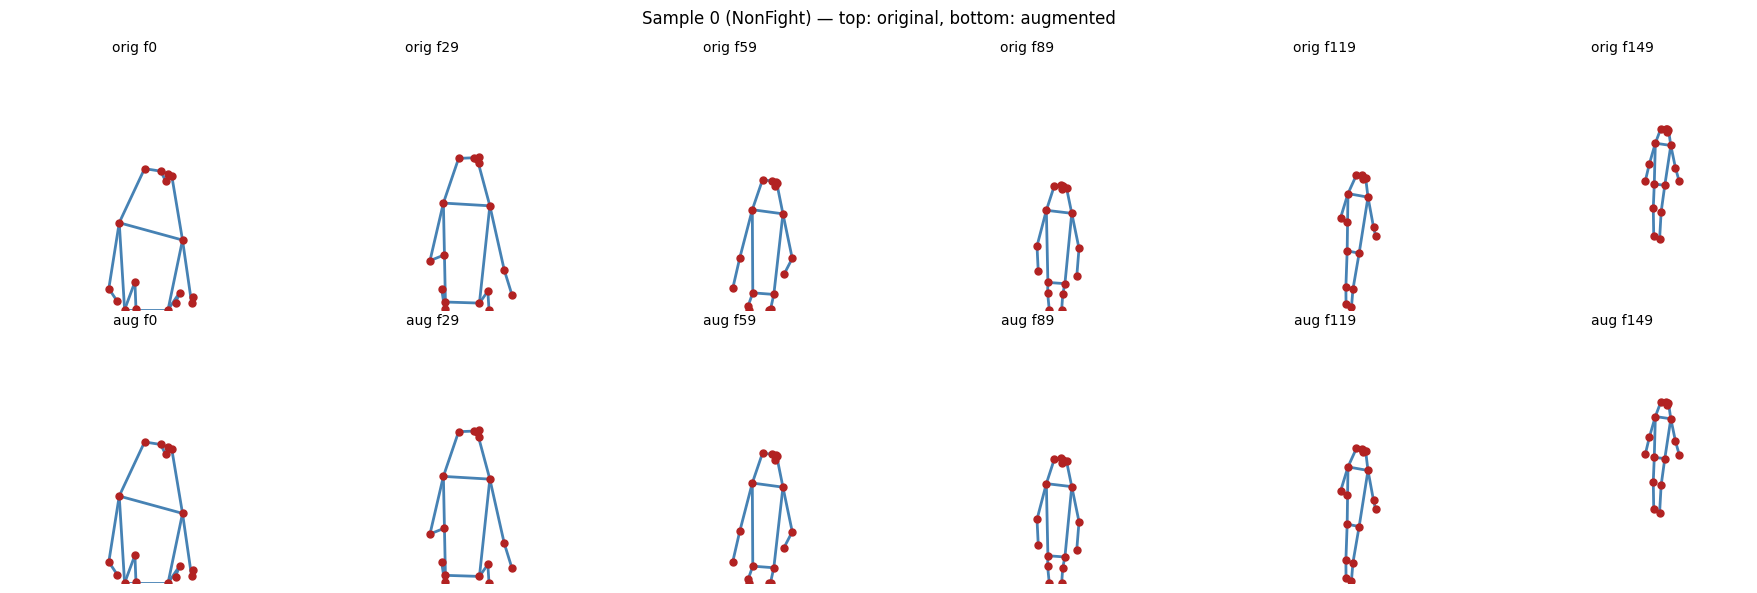

In [36]:
show_sample(sample_index=0, frames_to_show=6,  mode="diff")

Sample 1: 5/150 frames changed by augmentation


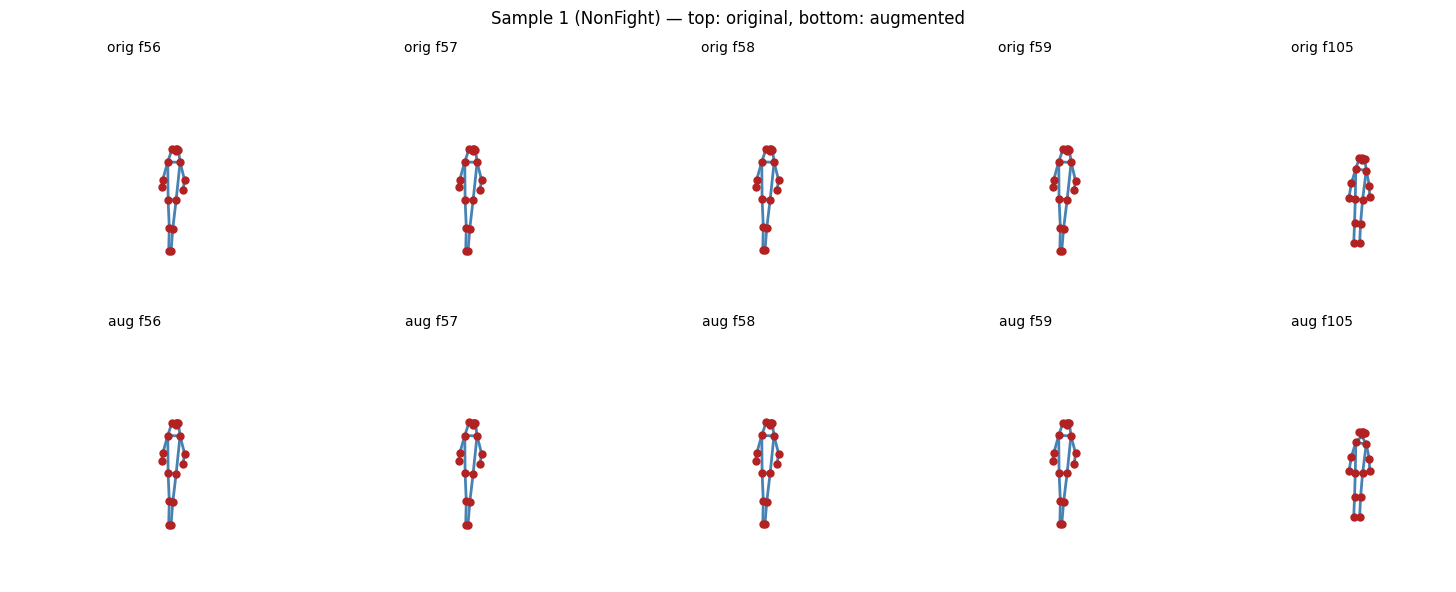

In [37]:
show_sample(sample_index=1, frames_to_show=6, mode="diff")

Sample 4: 14/150 frames changed by augmentation


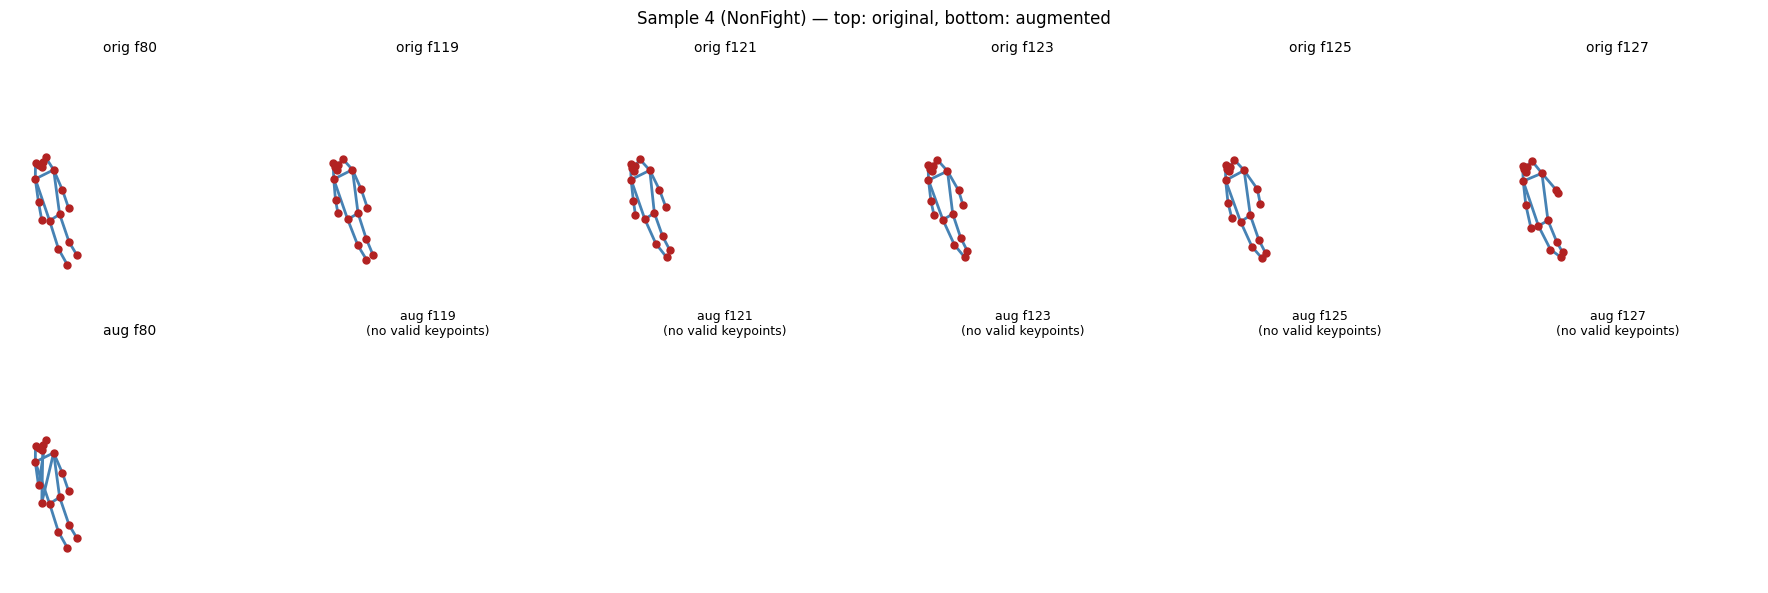

In [38]:
show_sample(sample_index=4, frames_to_show=6, mode="diff")

In [23]:
tensor, label = train_dataset[40]

augmented_tensor = augment_pose(tensor)

print("Original shape: ", tensor.shape)
print("Augmented shape:", augmented_tensor.shape)

print("Tensor changed:",
      not torch.equal(tensor, augmented_tensor))

difference = tensor != augmented_tensor

changed_frames = difference.any(dim=0).any(dim=1)

print("Changed frames:")
print(torch.where(changed_frames)[0].tolist())

Original shape:  torch.Size([3, 150, 17, 4])
Augmented shape: torch.Size([3, 150, 17, 4])
Tensor changed: True
Changed frames:
[1, 2, 3, 4, 5, 6, 49, 56, 66, 85, 94, 95, 96, 96, 97, 97, 98, 99, 100, 101, 102, 103, 104, 105, 105, 106, 106, 107, 107, 108, 108, 109, 109, 110, 110, 111, 111, 112, 112, 113, 113, 114, 114, 115, 115, 116, 116, 117, 117, 118, 119, 120, 121, 122, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 132, 133, 133, 134, 134, 135, 135, 136, 136, 137, 137, 138, 138, 139, 140, 141, 142, 143]


In [24]:
for person in range(tensor.shape[-1]):
    person_changed = not torch.equal(
        tensor[:, :, :, person],
        augmented_tensor[:, :, :, person],
    )

    print(f"Person {person}: {person_changed}")

Person 0: True
Person 1: True
Person 2: False
Person 3: False


In [25]:
print(
    augmented_tensor[:2].min().item(),
    augmented_tensor[:2].max().item(),
)

0.0 1.0
